In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [2]:
using Revise
includet("./base.jl")
import SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.MinimalModelV3

In [3]:
includet("../../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Making and saving plots

## Outcome phase diagram

In [4]:
function make_pd_plot(fname, sigmafi, outfname=nothing;
    outdir="./plots/",
    suffix=nothing,
    plotline_gpcols=[(1., 1., :black)],
)
    if isnothing(outfname)
        if isnothing(suffix)
            suffix = @sprintf "_sigmai_%d" sigmafi
        end
        bname, _ = splitext(basename(fname))
        outfname = joinpath(outdir, bname * suffix * ".pdf")
    end
    
    f = jldopen(fname)
    fmd = f["metadata"]
    leakxs = LeakageScale.ltox.(fmd.lmeans)
    
    df = f["df"]
    carrs = make_count_arrays(df);
    xx = collect(zip(carrs[1][:, :, sigmafi], carrs[2][:, :, sigmafi], carrs[3][:, :, sigmafi]))
    proportion_tuples = map(t -> t ./ sum(t), xx)
    
    cm = PaperColors.outcome_ternary_colormap()
    
    fig = Figure()
    ax = Axis(fig[1,1];
        xscale=log10,
        # xticks=log10ticks(-1:4),
        title=(@sprintf "fname=%s, sigmaf=%.5g" fname fmd.lsigmafs[sigmafi]),
        xlabel="Normalized energy supply rate",
        ylabel="Supplied resource leakage",
        xgridvisible=false,
        ygridvisible=false,
    )
    eps_ticks = [0.5, 0.3, 0.1, 0.01, 0.001]
    ax.yticks = (LeakageScale.etox.(eps_ticks), [(@sprintf "%.3g" (1-e)) for e in eps_ticks])
    ax.yminorticks = LeakageScale.exminorticks(eps_ticks, 4)
    
    sc = scatter!(ax, [(x, y) for x in fmd.Ks for y in leakxs];
        # marker='.',
        markersize=20,
        color=cm.(proportion_tuples)'[:]
    )
    
    for (gamma, p, color) in plotline_gpcols
        xx = extrema(leakxs)
        leakxs2 = range(xx[1], xx[2], 1000)
        ls2 = LeakageScale.l.(leakxs2)
    
        extline_Ks = MinimalModelV3.fr3_beta_viable.(ls2, gamma)
        instabline_Ks = MinimalModelV3.fr3_beta_s_qualified.(ls2, gamma, p)
    
        lines!(ax, extline_Ks, leakxs2;
            color,
            label=(@sprintf "beta_v with gamma=%.3g, p=%.3g" gamma p)
        )
        lines!(ax, instabline_Ks, leakxs2;
            color,
            linestyle=:dash,
            label=(@sprintf "beta_s with gamma=%.3g, p=%.3g" gamma p)
        )
    end
    axislegend(ax; position=:rb)
    
    close(f)

    Makie.save(outfname, fig)
    
    fig
end
function make_pd_plots(fname, args...; kwargs...)
    f = jldopen(fname)
    fmd = f["metadata"]
    n = length(fmd.lsigmafs)
    close(f)
    for i in 1:n
        make_pd_plot(fname, i, args...; kwargs...)
    end
end

make_pd_plots (generic function with 1 method)

In [5]:
# make_pd_plots("./main1.jld2"; outdir="main1_plots")
make_pd_plots("./main2.jld2"; outdir="main2_plots")

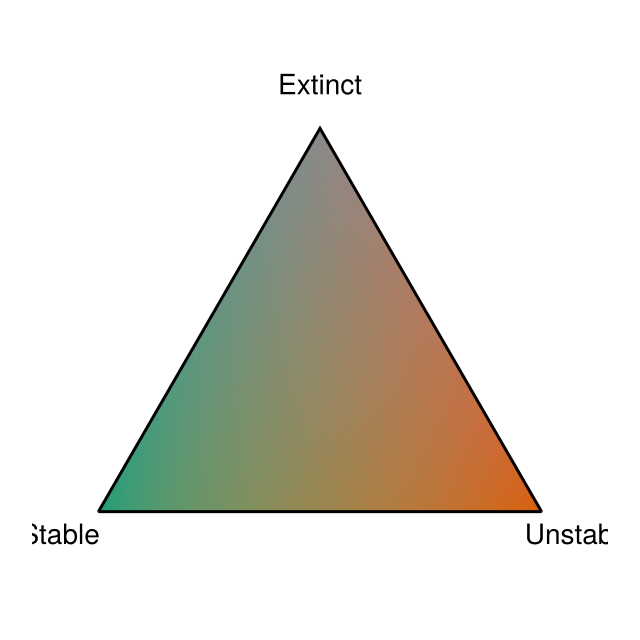

In [6]:
fig = TernaryColormaps.ternary_legend(PaperColors.outcome_ternary_colormap();
    labels=("Extinct", "Stable", "Unstable"),
    figure=(size=(320, 320),),
    ticks=[],
    # labeloffset=0.1,
)
Makie.save("./outcome_ternary_colormap.pdf", fig)
fig

## Outcome proportions vs K

In [7]:
function plot_outcome_proportions!(figpos, lmeani, lsigmafi; arrs=arrs, fmd=fmd, legend=true, show_bad=true)
    numKs, numlmeans, numlsigmafs = length(fmd.Ks), length(fmd.lmeans), length(fmd.lsigmafs)
    zeromat() = zeros(Int, numKs, numlmeans, numlsigmafs)

    good_codes = [1, 2, 3]
    good_labels = ["Extinct", "Stable", "Unstable"]
    good_colors = [PaperColors.extinct(), PaperColors.stable(), PaperColors.unstable()]

    counts = [get(arrs, code, zeromat())[:, lmeani, lsigmafi] for code in good_codes]
    totals = sum(get(arrs, code, zeromat())[:, lmeani, lsigmafi] for code in keys(arrs))
    bad_counts = totals .- sum(counts)

    ax = Axis(figpos;
        xscale=log10,
        xlabel="K",
        ylabel="Proportion",
        title=(@sprintf "lmean=%.4g, lsigmaf=%.4g" fmd.lmeans[lmeani] fmd.lsigmafs[lsigmafi]),
    )

    for (c, label, color) in zip(counts, good_labels, good_colors)
        plot_binom_sample!(ax, fmd.Ks, c, totals;
            proportions=true,
            color,
            sl_kwargs=(; label),
        )
    end
    if show_bad
        plot_binom_sample!(ax, fmd.Ks, bad_counts, totals;
            proportions=true,
            color=PaperColors.other(),
            sl_kwargs=(; label="Bad"),
        )
    end

    legend && axislegend(ax; position=:rt)
    ax
end
function plot_outcome_proportions_grid(fname; figure=(;), kwargs...)
    f = jldopen(fname)
    fmd = f["metadata"]
    df = f["df"]
    close(f)

    arrs = make_count_arrays(df)
    numlmeans, numlsigmafs = length(fmd.lmeans), length(fmd.lsigmafs)

    default_fig_kwargs = (; size=(350 * numlsigmafs, 300 * numlmeans + 50))
    fig = Figure(; merge(default_fig_kwargs, figure)...)
    for lmeani in 1:numlmeans, lsigmafi in 1:numlsigmafs
        plot_outcome_proportions!(fig[lmeani, lsigmafi], lmeani, lsigmafi; arrs, fmd, legend=false, kwargs...)
    end

    Legend(fig[numlmeans + 1, 1:numlsigmafs],
        [LineElement(; color) for color in (PaperColors.extinct(), PaperColors.stable(), PaperColors.unstable(), PaperColors.other())],
        ["Extinct", "Stable", "Unstable", "Bad"];
        orientation=:horizontal,
    )

    fig
end

plot_outcome_proportions_grid (generic function with 1 method)

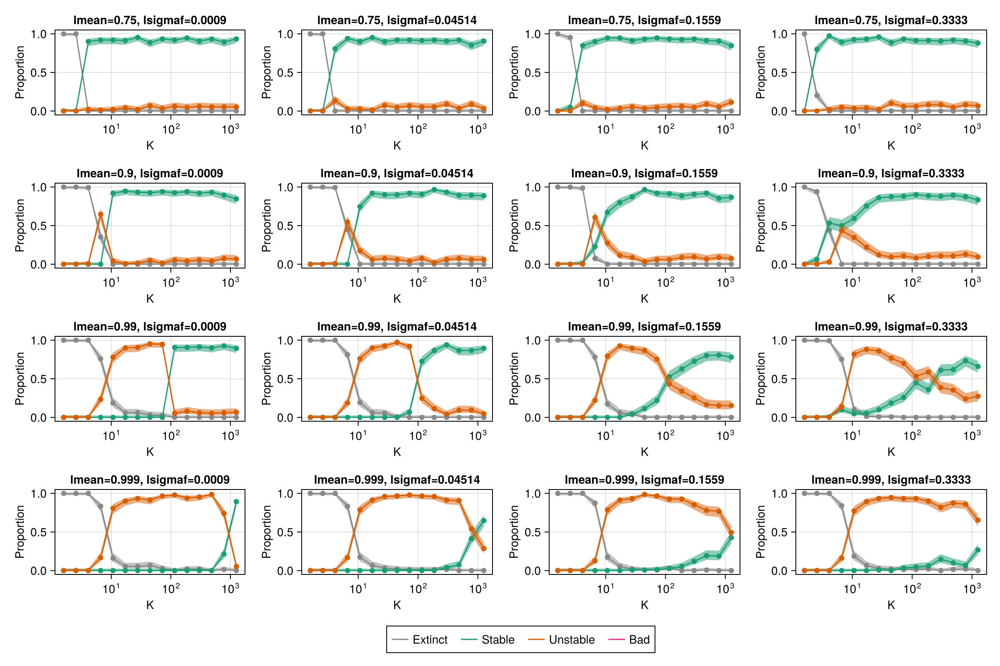

In [41]:
fig = plot_outcome_proportions_grid("./main1.jld2";
    figure=(; size=(1200, 800)),
    show_bad=false,
)
Makie.save("./main1_plots/proportions.pdf", fig)
fig

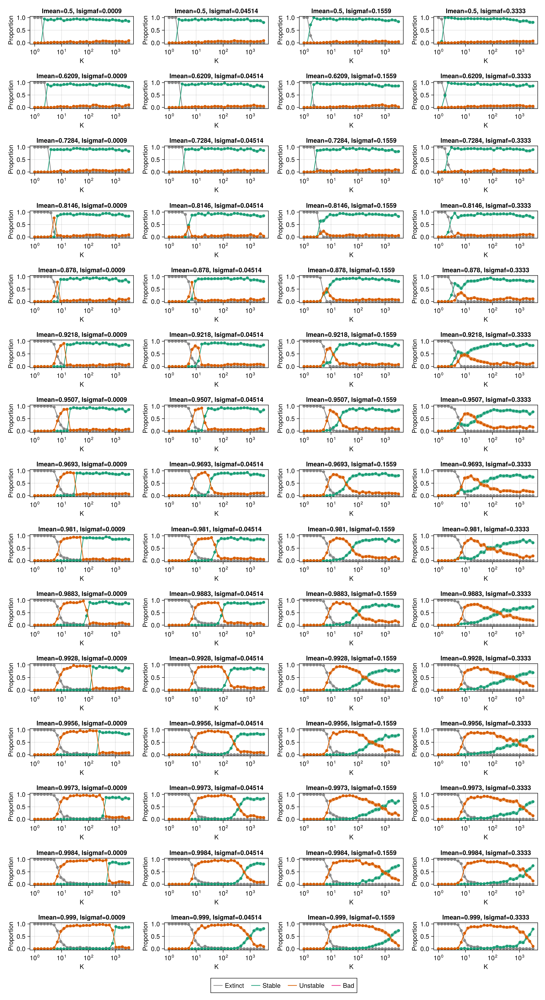

In [10]:
fig = plot_outcome_proportions_grid("./main2.jld2";
    figure=(; size=(1200, 2200)),
    show_bad=false,
)
Makie.save("./main2_plots/proportions.pdf", fig)
fig

## Beta distributions

In [6]:
function plot_beta_dists_panel!(figpos, mu, sigmafs;
    logscale=false,
    logitxscale=false,
    logit_xticks=[0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 0.999],
    logit_xlims=(1e-3, 1 - 1e-3),  # set to `nothing` to autolimit instead
)
    # on the logit axis sample uniformly in logit space, else the edges get a handful of points
    if logitxscale
        plot_xs = range(-16, 16; length=2001)
        xs = LeakageScale.l.(plot_xs)
    else
        xs = range(1e-6, 1 - 1e-6; length=2001)
        plot_xs = xs
    end

    ax = Axis(figpos;
        xlabel="x",
        ylabel="pdf",
        yscale=(logscale ? log10 : identity),
        title=(@sprintf "mu=%.4g" mu),
    )
    if logitxscale
        ax.xticks = LeakageScale.lxticks(logit_xticks; fmt="%.3g")
        ax.xticklabelrotation = pi / 4
        ax.xminorticksvisible = true
        ax.xminorticks = LeakageScale.lxminorticks(logit_xticks, 4)
        isnothing(logit_xlims) || xlims!(ax, LeakageScale.ltox.(logit_xlims)...)
    end

    peak = 0.0
    for sigmaf in sigmafs
        sigma = sigmaf * max_sigma_not_bimodal(mu)
        y = pdf.(beta_from_mean_std(mu, sigma), xs)
        # density wrt the plotted coordinate, so dl/dx = l(1-l) comes along
        logitxscale && (y = y .* xs .* (1 .- xs))
        peak = max(peak, maximum(filter(isfinite, y)))
        lines!(ax, plot_xs, y; linewidth=2, label=(@sprintf "sigmaf=%.3g" sigmaf))
    end
    ylims!(ax, logscale ? (eps(), 2 * peak) : (0, 1.05 * peak))

    ax
end
function plot_beta_dists_grid(fname; nmeans=5, logscale=true, logit_kwargs=(;), figure=(;))
    f = jldopen(fname)
    fmd = f["metadata"]
    close(f)

    # nmeans indices spread across the available means, including the first and last
    meanis = round.(Int, range(1, length(fmd.lmeans), nmeans))

    default_fig_kwargs = (; size=(320 * nmeans + 40, 500))
    fig = Figure(; merge(default_fig_kwargs, figure)...)
    local ax1
    for (i, meani) in enumerate(meanis)
        ax = plot_beta_dists_panel!(fig[1, i], fmd.lmeans[meani], fmd.lsigmafs; logscale, logitxscale=false)
        i == 1 && (ax1 = ax)
    end
    for (i, meani) in enumerate(meanis)
        plot_beta_dists_panel!(fig[2, i], fmd.lmeans[meani], fmd.lsigmafs; logscale, logitxscale=true, logit_kwargs...)
    end

    Label(fig[1, 0], "linear x"; rotation=pi / 2, tellheight=false, fontsize=14, font=:bold)
    Label(fig[2, 0], "logit x"; rotation=pi / 2, tellheight=false, fontsize=14, font=:bold)
    Legend(fig[3, 1:nmeans], ax1; orientation=:horizontal, tellwidth=false)

    fig
end

plot_beta_dists_grid (generic function with 1 method)

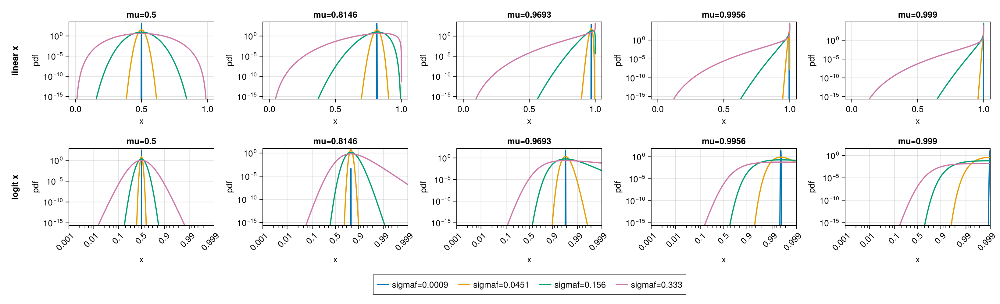

In [9]:
mkpath("./main2_plots")

fig = plot_beta_dists_grid("./main2.jld2")
Makie.save("./main2_plots/beta_dists.pdf", fig)
fig

# Playing around

In [15]:
f = jldopen("./main1.jld2")

fmd = f["metadata"]
# leakxs = LeakageScale.ltox.(fmd.lis)

df = f["df"]
arrs = make_count_arrays(df);
sort(collect(keys(arrs)))

6-element Vector{Int64}:
 -3
 -2
 -1
  1
  2
  3

# Looking at the beta dists

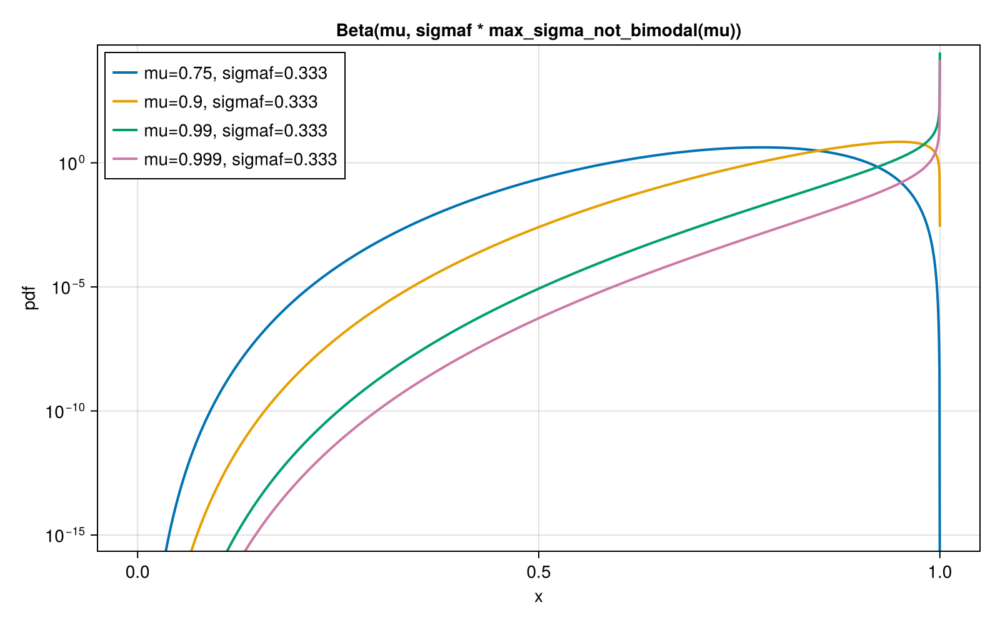

In [17]:
# --- Choices ---
mu_sigmaf_list = [
    (fmd.lmeans[1], fmd.lsigmafs[1]),
    (fmd.lmeans[1], fmd.lsigmafs[end]),
    (fmd.lmeans[end], fmd.lsigmafs[1]),
    (fmd.lmeans[end], fmd.lsigmafs[end]),
]
mu_sigmaf_list = [(mu, sf) for mu in fmd.lmeans for sf in fmd.lsigmafs]
mu_sigmaf_list = [(mu, fmd.lsigmafs[end]) for mu in fmd.lmeans]

logscale = true  # toggle: true for log10 y-axis, false for linear

xs = range(1e-6, 1 - 1e-6; length=2001)

fig = Figure(size=(800, 500))
ax = Axis(fig[1, 1];
    xlabel="x",
    ylabel="pdf",
    yscale=(logscale ? log10 : identity),
    title="Beta(mu, sigmaf * max_sigma_not_bimodal(mu))",
)

peak = 0.0
for (mu, sigmaf) in mu_sigmaf_list
    sigma = sigmaf * max_sigma_not_bimodal(mu)
    y = pdf.(beta_from_mean_std(mu, sigma), xs)
    peak = max(peak, maximum(filter(isfinite, y)))
    lines!(ax, xs, y; linewidth=2, label="mu=$(round(mu, digits=3)), sigmaf=$(round(sigmaf, digits=3))")
end

ylims!(ax, logscale ? (eps(), 2 * peak) : (0, 1.05 * peak))
axislegend(ax; position=:lt)

# Makie.save("./main1_plots/betas_minsigma.pdf", fig)

fig

In [20]:
fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1]; xlabel="x", ylabel="pdf")
xlims!(ax, 0, 1)

sg = SliderGrid(fig[2, 1],
    (label="logit(mu)", range=-8:0.01:8, startvalue=0.0, format="{:.2f}"),
    (label="log10(sigma)", range=-4:0.01:-0.31, startvalue=-1.0, format="{:.2f}"),
)
mux = sg.sliders[1].value
logsigma = sg.sliders[2].value

tg = GridLayout(fig[3, 1]; tellwidth=false)
logy = Toggle(tg[1, 1]; active=false)
Label(tg[1, 2], "log10 y-axis")

# grid uniform in logit space, so the edges stay resolved
xs = LeakageScale.l.(range(-16, 16; length=5001))
ys = lift(mux, logsigma) do mx, ls
    mu = LeakageScale.l(mx)
    sigma = 10 ^ ls
    sigma^2 < mu * (1 - mu) ? clamp.(pdf.(beta_from_mean_std(mu, sigma), xs), eps(), Inf) : fill(NaN, length(xs))
end

lines!(ax, xs, ys; linewidth=2)
on(logy.active) do uselog
    if uselog
        # autolimits on a log axis would span the whole tail, ~200 decades
        ymax = maximum(filter(isfinite, ys[]); init=1.0)
        ylims!(ax, ymax / 1e10, 2 * ymax)
        ax.yscale = log10
    else
        ax.yscale = identity
        ylims!(ax, nothing, nothing)
    end
end

Label(fig[0, 1], lift(mux, logsigma) do mx, ls
    mu = LeakageScale.l(mx)
    sigma = 10 ^ ls
    max_allowable_sigma_ = max_allowable_sigma(mu)
    max_unimodal_sigma = max_sigma_for_unimodal(mu)
    max_not_bimodal_sigma = max_sigma_not_bimodal(mu)
    caps = @sprintf "max_allowable_sigma=%.4g   max_sigma_for_unimodal=%.4g   max_sigma_not_bimodal=%.4g" max_allowable_sigma_ max_unimodal_sigma max_not_bimodal_sigma
    if sigma < max_allowable_sigma_
        d = beta_from_mean_std(mu, sigma)
        a, b = params(d)
        @sprintf("mu=%.4g, sigma=%.4g  ->  Beta(alpha=%.4g, beta=%.4g)\n%s", mu, sigma, a, b, caps)
    else
        @sprintf("mu=%.4g, sigma=%.4g  invalid, sigma must be < %.4g\n%s", mu, sigma, max_allowable_sigma_, caps)
    end
end, tellwidth=false)

display(GLMakie.Screen(), fig)

GLMakie.Screen(...)